# Tests Scores:

In [1]:
import sys
sys.path.append('../')
sys.path.append('./git_clone_liibraries/')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
from speechbrain.pretrained import SpeakerRecognition
import pickle
import os
from utils.my_classes import dataset
import utils.eval_metrics as eval_metrics
import copy
from speechbrain.pretrained import SpeakerRecognition
# Plot histogram of predicted probabilities
from matplotlib.ticker import PercentFormatter
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
import scipy
# Plot histogram of predicted probabilities
from matplotlib.ticker import PercentFormatter
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression


seed = 42  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\torch\onnx\_internal\_beartype.py:35: UserWarning: unhashable type: 'list'
  warnings.warn(f"{e}")
The torchaudio backend is switched to 'soundfile'. Note that 'sox_io' is not supported on Windows.
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\speechbrain\utils\torch_audio_backend.py:22: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaud

In [2]:
#To get my GPU device - GTX 4070 :)
seed = 42  # You can choose any integer value as the seed
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


# loading the embedding for CM System:

In [3]:
from ASV_utils.data_loading import *



models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/pmf_both/not_normalize/male/"

data_path_female = "Data/pmf_both/not_normalize/female/"

male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id,male_chosen_labels_3_1_speaker_id,male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex  = load_data_male(data_path_male)

female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex  = load_data_female(data_path_female)

# Pre Processing the channels And loading the Models - Male & Female:

In [4]:

import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,true_channels_indexes]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,true_channels_indexes]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,true_channels_indexes]

male_embedded_groups_1_1 = male_embedded_groups_1_1[:,true_channels_indexes]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,true_channels_indexes]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,true_channels_indexes]

In [5]:
from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
male_embedded_groups_1_1 = male_embedded_groups_1_1[:,list(index_mapping.keys())]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,list(index_mapping.keys())]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,list(index_mapping.keys())]

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,list(index_mapping.keys())]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,list(index_mapping.keys())]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,list(index_mapping.keys())]



In [6]:
# define the subchannel model network
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
import pickle
# define the subchannel model network
import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 

        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        return x

# define the model network
class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.loss = nn.BCEWithLogitsLoss()
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)



# Just for checking the model and see the number of parameters
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 5
final_output_size = 1
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size)
model = model.to(device)
print(model)
n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)
model = model.to(device) # send the model to the device

model = pickle.load(open(models_folder + "CM_both_male_9_2.pkl", 'rb'))

model.eval()

spoof_model_male = copy.deepcopy(model)

DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=5, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=80, out_features=40, bias=True)
  (BN): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=40, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): BCEWithLogitsLoss()
)
Number of parameters: 4401


In [7]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

r_real = 0.5 
r_fake = 0.1
alpha = 20
# Example usage
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 10
final_output_size = 16*3
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)


model = model.to(device) # send the model to the device

model = pickle.load(open(models_folder + "CM_both_female_10_17.pkl", 'rb'))

model.eval()

spoof_model_female = copy.deepcopy(model)


In [8]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,80)
        self.BN = nn.BatchNorm1d(80)
        self.fc = nn.Linear(80, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)


r_real = 0.9 
r_fake = 0.5
alpha = 20
input_channel_size = 10
output_channel_size = 10
num_SubChannelNetwork = 16
final_output_size = 16*2
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)
model = model.to(device)


model = model.to(device) # send the model to the device

file_path = 'ECAPA_TDNN/inference_models/models_both_not_normalize/male_and_female_2_neorun_end_OCS_both_10_2.pkl'

# Load the variable from the pickle file
with open(file_path, 'rb') as file:
    model = pickle.load(file)

model.eval()

spoof_model = copy.deepcopy(model)


In [9]:
scaler_male = StandardScaler(with_mean = True, with_std = True)
scaler_male.fit(male_embedded_groups_1_1)
mean_features = scaler_male.mean_
std_features = scaler_male.scale_
male_embedded_groups_1_1_norm = scaler_male.transform(male_embedded_groups_1_1)
male_embedded_groups_1_2_norm = scaler_male.transform(male_embedded_groups_1_2)
male_embedded_groups_1_3_norm = scaler_male.transform(male_embedded_groups_1_3)


scaler_female = StandardScaler(with_mean = True, with_std = True)
scaler_female.fit(female_embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
female_embedded_groups_1_1_norm = scaler_female.transform(female_embedded_groups_1_1)
female_embedded_groups_1_2_norm = scaler_female.transform(female_embedded_groups_1_2)
female_embedded_groups_1_3_norm = scaler_female.transform(female_embedded_groups_1_3)

In [10]:
embedded_groups_1_1_norm,embedded_groups_1_2_norm,embedded_groups_1_3_norm,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex    =  concatenate_data(male_embedded_groups_1_1_norm,male_embedded_groups_1_2_norm,male_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_embedded_groups_1_1_norm,female_embedded_groups_1_2_norm,female_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)


In [11]:
embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,
                                                                                                                        male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                        male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                        male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                        male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                        male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                        male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                        
                                                                                                                        female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,
                                                                                                                        female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                        female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                        female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                        female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                        female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                        female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
scaler_all = StandardScaler(with_mean = True, with_std = True)
scaler_all.fit(embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
embedded_groups_1_1_all = scaler_all.transform(embedded_groups_1_1)
embedded_groups_1_2_all = scaler_all.transform(embedded_groups_1_2)
embedded_groups_1_3_all = scaler_all.transform(embedded_groups_1_3)

In [12]:
train_dataset_all = dataset(data = embedded_groups_1_1_norm , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id, sex = chosen_labels_1_1_sex ,data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_1_all);

Dev_dataset_all = dataset(data = embedded_groups_1_2_norm , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,  data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_2_all);


Eval_dataset_all = dataset(data = embedded_groups_1_3_norm , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex , data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_3_all);


In [13]:
from ASV_utils.data_loading import *


models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/male_vs_female_DB_models/16_bits/none/male/"

data_path_female = "Data/male_vs_female_DB_models/16_bits/none/female/"

g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_male(data_path_male)

g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_female(data_path_female)

embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,
                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                    
                                                                                                                    g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,
                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
chosen_labels_1_1_sex = np.array([elem[0] for elem in chosen_labels_1_1_sex])
                                 
chosen_labels_2_1_sex = np.array([elem[0] for elem in chosen_labels_2_1_sex])

chosen_labels_3_1_sex = np.array([elem[0] for elem in chosen_labels_3_1_sex])


In [14]:



import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)


embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    

embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]


columns_names = columns_names[list(index_mapping.keys())]

In [15]:
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(embedded_groups_1_1)
mean_features = scaler.mean_
std_features = scaler.scale_

embedded_groups_1_1 = scaler.transform(embedded_groups_1_1)
embedded_groups_1_2 = scaler.transform(embedded_groups_1_2)
embedded_groups_1_3 = scaler.transform(embedded_groups_1_3)

train_dataset_all.data_for_gender_classification = embedded_groups_1_1
Dev_dataset_all.data_for_gender_classification   = embedded_groups_1_2
Eval_dataset_all.data_for_gender_classification  = embedded_groups_1_3


train_dataset_all.sex = pd.Series([elem[0] for elem in train_dataset_all.sex])
Dev_dataset_all.sex = pd.Series([elem[0] for elem in Dev_dataset_all.sex])
Eval_dataset_all.sex = pd.Series([elem[0] for elem in Eval_dataset_all.sex])


train_dataset_all.name = pd.Series([elem[0] for elem in train_dataset_all.name])
Dev_dataset_all.name = pd.Series([elem[0] for elem in Dev_dataset_all.name])
Eval_dataset_all.name = pd.Series([elem[0] for elem in Eval_dataset_all.name])

In [16]:
# import scipy.stats as stats
# from scipy import stats
# p_values = []
# selected_features = []
# alpha = 0.05
# for feature_index in range(embedded_groups_1_1.shape[1]):
#     t_stat, p_value = stats.ttest_ind(embedded_groups_1_1[train_dataset_all.is_spoofed == 0,feature_index], embedded_groups_1_1[train_dataset_all.is_spoofed == 1,feature_index],equal_var=False)
#     p_values.append(p_value)
    
# selected_features = [columns_names[i] for i, p in enumerate(p_values) if p < alpha]

In [16]:
total_labels_dev_male = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data_dev_male = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    #test_score_dev_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data_dev_male).to(device)))
    test_score_dev_male = spoof_model_male(torch.Tensor(total_data_dev_male).to(device))
    
test_score_dev_male = test_score_dev_male.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_dev_male,expit(test_score_dev_male)) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.007981601731367872%) 	Test Threshold: 0.15829723633162024


In [17]:
total_labels_eval_male = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data_eval_male = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    #test_score_eval_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data_eval_male).to(device)))
    test_score_eval_male = spoof_model_male(torch.Tensor(total_data_eval_male).to(device))
    
test_score_eval_male = test_score_eval_male.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_eval_male,expit(test_score_eval_male)) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")


	Test EER: (0.09203296703296708%) 	Test Threshold: 0.04938841153161375


In [18]:
total_labels_dev_female = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data_dev_female = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_output = spoof_model_female(torch.Tensor(total_data_dev_female).to(device))
    loss , test_score_dev_female = spoof_model_female.loss(torch.Tensor(test_output).to(device),None)
    test_score_dev_female = -1*test_score_dev_female
    
test_score_dev_female = test_score_dev_female.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_dev_female,test_score_dev_female) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.0%) 	Test Threshold: nan


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in true_divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [19]:
total_labels_eval_female = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data_eval_female = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_output = spoof_model_female(torch.Tensor(total_data_eval_female).to(device))
    loss , test_score_eval_female = spoof_model_female.loss(torch.Tensor(test_output).to(device),None)
    test_score_eval_female = -1*test_score_eval_female
    
test_score_eval_female = test_score_eval_female.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels_eval_female,test_score_eval_female) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.10177271288382395%) 	Test Threshold: -0.8237718060240031


In [20]:
dev_labels_all = torch.Tensor(Dev_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    validation_output = spoof_model(torch.Tensor(total_data).to(device)).cpu()
    loss , validation_score = spoof_model.loss(torch.Tensor(validation_output).to(device),torch.LongTensor(dev_labels_all).to(device))
    validation_score = -1*validation_score


dev_score_all = validation_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(dev_labels_all,dev_score_all) # compute equal error rate
print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.039246467900462476%) 	Test Threshold: -0.9427753686997667


In [21]:
eval_labels_all = torch.Tensor(Eval_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    test_output = spoof_model(torch.Tensor(total_data).to(device))
    _ , test_score = spoof_model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(eval_labels_all).to(device))
    test_score = -1*test_score
    
eval_score_all = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(eval_labels_all,eval_score_all) # compute equal error rate


print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (10.273629504398746%) 	Test Threshold: -0.996142029976868


In [23]:
import numpy as np
import sklearn.metrics
from confidence_intervals import evaluate_with_conf_int
from confidence_intervals import get_bootstrap_indices, get_conf_int
from confidence_intervals.utils import barplot_with_ci
import warnings
warnings.filterwarnings("ignore")
# Percentage for the confidence interval
alpha = 5 

# Number of bootstrap samples to use (the run time will be proportional to this number). We set it to
# 50/alpha*100 to get enough samples in the tails.
num_bootstraps = int(50/alpha*100)

print(" Number of bootstraps: ", num_bootstraps)
print(" Alpha: ", alpha)

def metric(labels, scores):
    eer, _ = my_functions.compute_eer(labels, scores)
    if eer == 0:
        epsilon = 1e-10
        eer = eer + epsilon
    return eer

##Male:

labels = total_labels_dev_male
scores = expit(test_score_dev_male).flatten()
speakers = Dev_dataset_all.speaker_id[(Dev_dataset_all.sex == 'male').values].values
res_dev_male = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)

labels = total_labels_eval_male
scores = expit(test_score_eval_male).flatten()
speakers = Eval_dataset_all.speaker_id[(Eval_dataset_all.sex == 'male').values].values
res_eval_male = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)

##Female:

labels = total_labels_dev_female
scores = test_score_dev_female
speakers = Dev_dataset_all.speaker_id[(Dev_dataset_all.sex == 'female').values].values
res_dev_female = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, num_bootstraps=num_bootstraps, alpha=alpha)

labels = total_labels_eval_female
scores = test_score_eval_female
speakers = Eval_dataset_all.speaker_id[(Eval_dataset_all.sex == 'female').values].values

res_eval_female = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)

#All:
labels = dev_labels_all
scores = dev_score_all
speakers = Dev_dataset_all.speaker_id.values
res_dev_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)


labels = eval_labels_all
scores = eval_score_all
speakers = Eval_dataset_all.speaker_id.values
res_eval_all = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speakers, num_bootstraps=num_bootstraps, alpha=alpha)


data = {}
data['Male'] = {'Dev': res_dev_male, 'Eval': res_eval_male}
data['Female'] = {'Dev': res_dev_female, 'Eval': res_eval_female}
data['all'] = {'Dev': res_dev_all, 'Eval': res_eval_all}

 Number of bootstraps:  1000
 Alpha:  5


{'Dev': (0.007981601731367872, (0.003441957145706685, 0.011445355616016844)), 'Eval': (0.09203296703296708, (0.07892956024893542, 0.1035649810028366))}
{'Dev': (1e-10, (1e-10, 1e-10)), 'Eval': (0.10177271288382395, (0.08617058895301757, 0.11654994808032579))}
{'Dev': (0.00039246467900462474, (1e-10, 0.0010664381743382863)), 'Eval': (0.10273629504398746, (0.0886186562379285, 0.1189705809676383))}


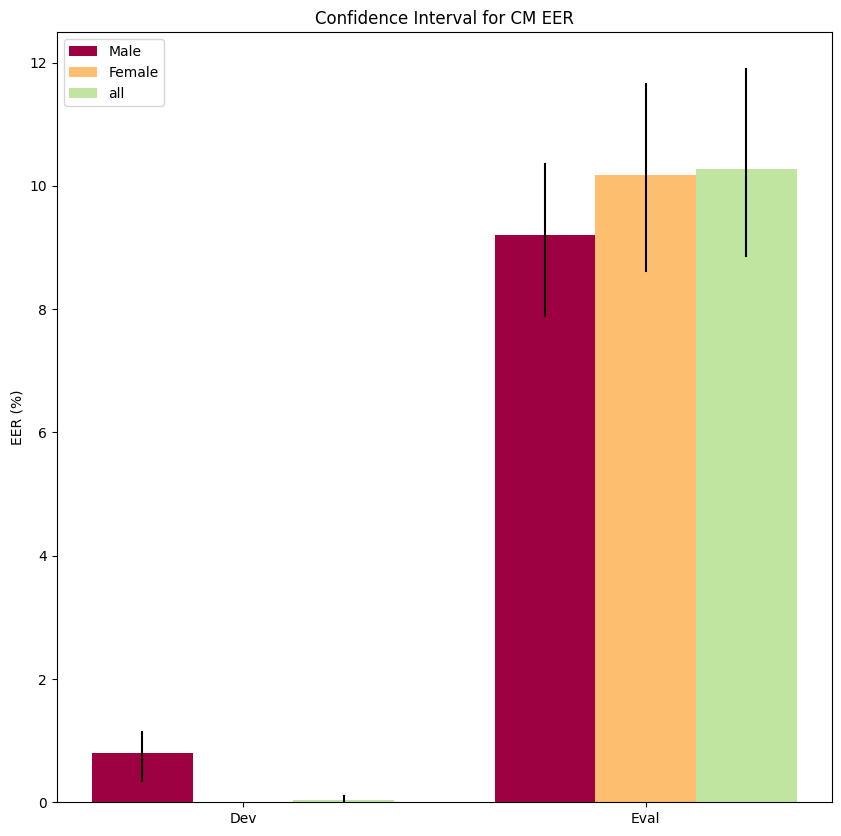

In [24]:
barplot_with_ci(data, figsize=(10,10),y_limit = [1,1],eer = True,title = 'Confidence Interval for CM EER')

# Speaker Verefication how i think:

{'Dev': (0.003409090917557478, (0.0, 0.009547155350446701)), 'Eval': (0.006284092552959919, (0.0016804458049591632, 0.012092555593699216))}
{'Dev': (0.010812490247189999, (0.0, 0.023984636645764112)), 'Eval': (0.007865151390433311, (0.00403869531583041, 0.013218985521234572))}
{'Dev': (0.013499986380338669, (0.004033677093684673, 0.024837084813043475)), 'Eval': (0.008009485900402069, (0.004727866593748331, 0.011824975069612264))}


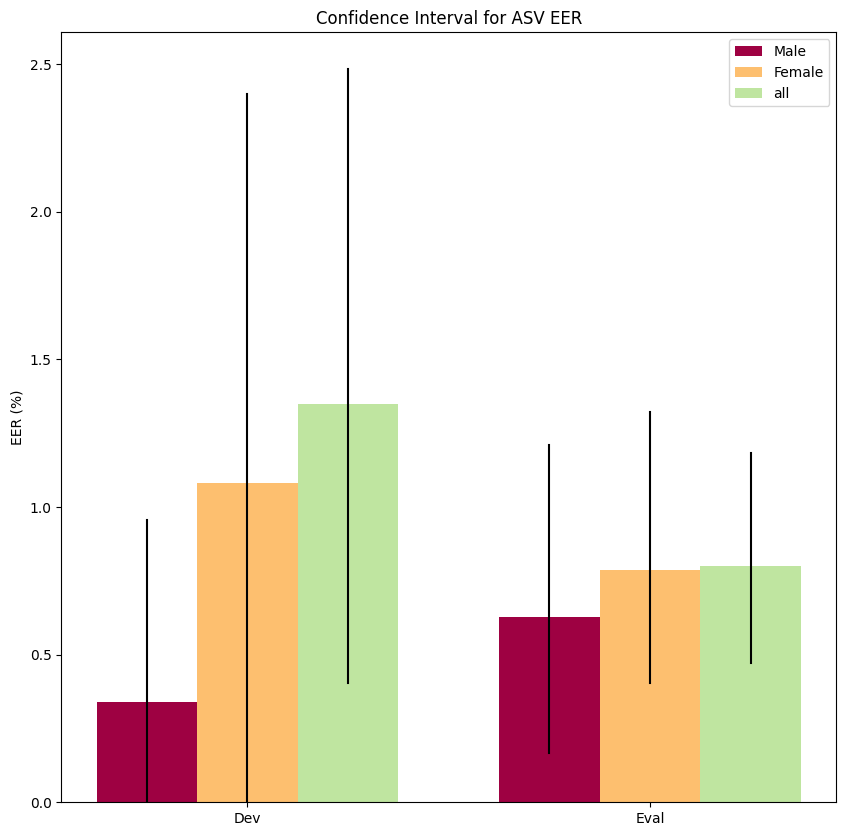

In [25]:
import pickle
from git_clone_liibraries.DCA_PLDA.dca_plda.scores import Key,Scores,Det
# Create a toy dataset. Here the samples are simply the decisions made by the system.
N0 = 200
N1 = 200
NC = 20
# Percentage for the confidence interval
alpha = 5 

# Number of bootstrap samples to use (the run time will be proportional to this number). We set it to
# 50/alpha*100 to get enough samples in the tails.
num_bootstraps = int(50/alpha*100)
ptar = 0.99

def metric(labels, scores):
    tar = scores[labels == 1]
    non = scores[labels == 0]
    det_all = Det(tar, non, False)
    mdcf_all  = det_all.min_dcf(ptar)
    adcf_all  = det_all.act_dcf(ptar)
    mcllr_all = det_all.min_cllr(ptar)
    acllr_all = det_all.act_cllr(ptar)
    eer_all   = det_all.eer()
    return eer_all #, mdcf_all, adcf_all, mcllr_all, acllr_all


def eval_asv_wrapper(file_path: str):
    results_list = pickle.load(open(file_path, 'rb'))
    scores =  results_list['pred_scores'].values
    label_ground_truth = results_list['label_ground_truth'].values
    mapping = {'target': 1, 'nontarget': 0, 'spoof': -1}
    # Apply the mapping to the array
    labels = np.array([mapping[value] for value in label_ground_truth])
    #get the indexs with labels -1
    mask = labels != -1
    labels = labels[mask]
    speaker_id = results_list['speaker_id'].values
    speaker_id = speaker_id[mask]
    scores = scores[mask]
    speaker_id_two_numbers = np.array([int(x[-2:]) for x in speaker_id])
    res = evaluate_with_conf_int(samples = scores, metric = metric, labels = labels, conditions = speaker_id_two_numbers, num_bootstraps=num_bootstraps, alpha=alpha)
    return res

def plot_eval_asv_metric_wrapper(eer: bool = True  ,title : str = '' ):
    file_path = './dcf_and_tdcf/dcf_avg_score/dcf/correct_flac_files/asv_results_dev_fixed_male.pkl'
    res_dev_male = eval_asv_wrapper(file_path)
    file_path = './dcf_and_tdcf/dcf_avg_score/dcf/correct_flac_files/asv_results_dev_fixed_female.pkl'
    res_dev_female = eval_asv_wrapper(file_path)
    file_path = './dcf_and_tdcf/dcf_avg_score/dcf/correct_flac_files/asv_results_dev_fixed_all.pkl'
    res_dev_all = eval_asv_wrapper(file_path)
    file_path = './dcf_and_tdcf/dcf_avg_score/dcf/correct_flac_files/asv_results_eval_fixed_male.pkl'
    res_eval_male = eval_asv_wrapper(file_path)
    file_path = './dcf_and_tdcf/dcf_avg_score/dcf/correct_flac_files/asv_results_eval_fixed_female.pkl'
    res_eval_female = eval_asv_wrapper(file_path)
    file_path = './dcf_and_tdcf/dcf_avg_score/dcf/correct_flac_files/asv_results_eval_fixed_all.pkl'
    res_eval_all = eval_asv_wrapper(file_path)
    data = {}
    data['Male'] = {'Dev': res_dev_male, 'Eval': res_eval_male}
    data['Female'] = {'Dev': res_dev_female, 'Eval': res_eval_female}
    data['all'] = {'Dev': res_dev_all, 'Eval': res_eval_all}
    barplot_with_ci(data, figsize=(10,10),y_limit = [1,1],eer = eer,title = title)

plot_eval_asv_metric_wrapper(eer = True,title = 'Confidence Interval for ASV EER')

{'Dev': (array(0.02353896), (0.0, 0.038336539175361395)), 'Eval': (array(0.04586466), (0.0031182778533548113, 0.06716774869710206))}
{'Dev': (array(0.09986772), (0.0, 0.14420372135937212)), 'Eval': (array(0.1467008), (0.027198865218088033, 0.30323608228209187))}
{'Dev': (array(0.22738989), (0.023040342377498746, 0.285596804009401)), 'Eval': (array(0.1297214), (0.0374138031154871, 0.24948342562129233))}


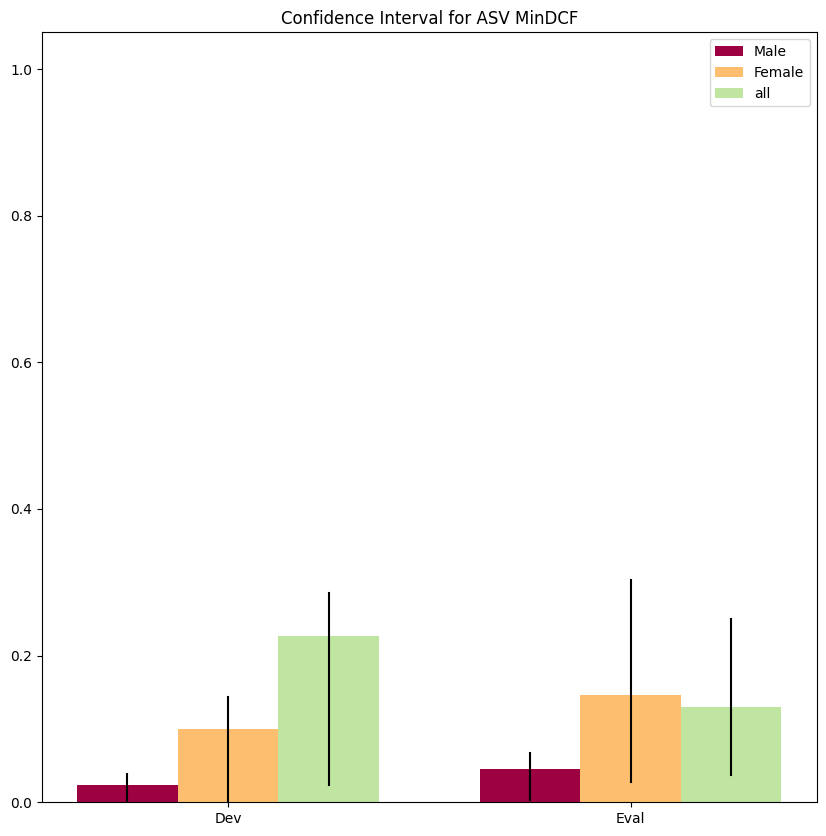

In [26]:
def metric(labels, scores):
    tar = scores[labels == 1]
    non = scores[labels == 0]
    det_all = Det(tar, non, False)
    mdcf_all  = det_all.min_dcf(ptar)
    adcf_all  = det_all.act_dcf(ptar)
    mcllr_all = det_all.min_cllr(ptar)
    acllr_all = det_all.act_cllr(ptar)
    eer_all   = det_all.eer()
    return mdcf_all #, mdcf_all, adcf_all, mcllr_all, acllr_all

plot_eval_asv_metric_wrapper(eer = False,title = 'Confidence Interval for ASV MinDCF')


{'Dev': (array(1.), (1.0, 1.0)), 'Eval': (array(1.), (1.0, 1.0))}
{'Dev': (array(1.), (1.0, 1.0)), 'Eval': (array(1.), (1.0, 1.0))}
{'Dev': (array(1.), (1.0, 1.0)), 'Eval': (array(1.), (1.0, 1.0))}


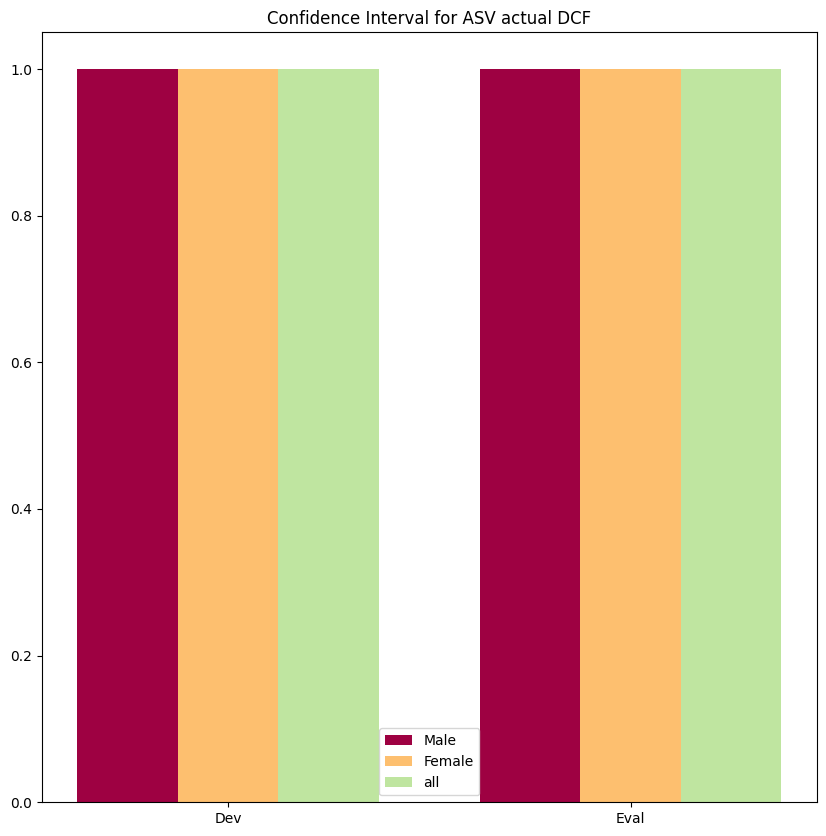

In [35]:
def metric(labels, scores):
    tar = scores[labels == 1]
    non = scores[labels == 0]
    det_all = Det(tar, non, False)
    mdcf_all  = det_all.min_dcf(ptar)
    adcf_all  = det_all.act_dcf(ptar)
    mcllr_all = det_all.min_cllr(ptar)
    acllr_all = det_all.act_cllr(ptar)
    eer_all   = det_all.eer()
    return adcf_all #, mdcf_all, adcf_all, mcllr_all, acllr_all

plot_eval_asv_metric_wrapper(eer = False,title = 'Confidence Interval for ASV actual DCF')

{'Dev': (array(0.02766844), (7.958310416209019e-06, 0.05097397515166091)), 'Eval': (array(0.04113813), (0.006916870012065242, 0.06952926572411137))}
{'Dev': (array(0.08687711), (5.104775085376972e-05, 0.1347252885572703)), 'Eval': (array(0.14107685), (0.027850911588923003, 0.27188604708708913))}
{'Dev': (array(0.12146289), (0.029849651765324926, 0.18572140633888712)), 'Eval': (array(0.11948275), (0.034800927135605064, 0.22494138948118358))}


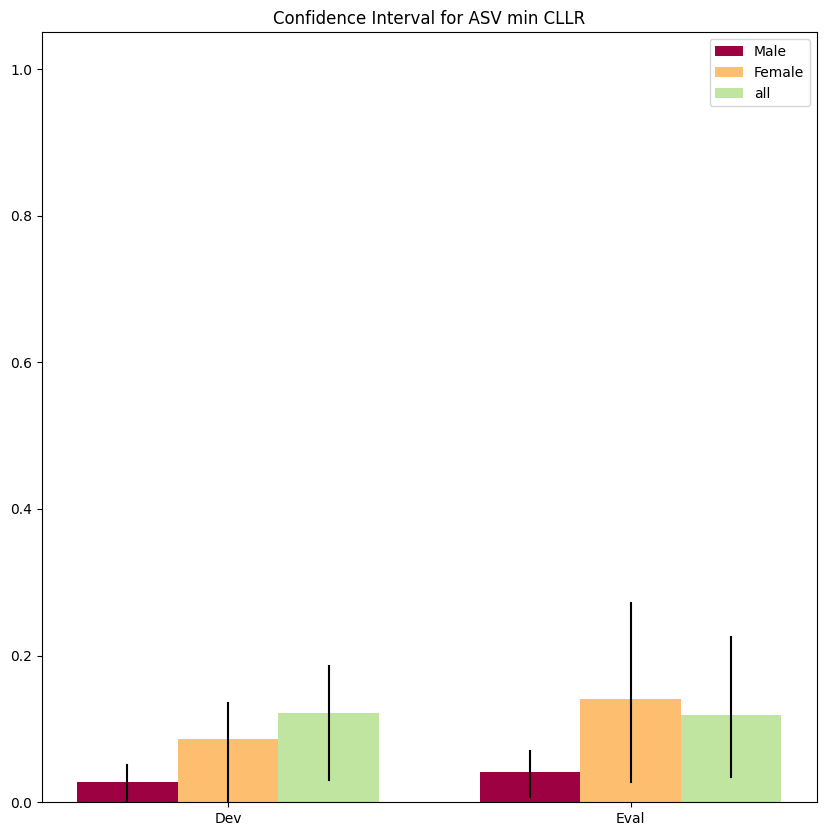

In [36]:
def metric(labels, scores):
    tar = scores[labels == 1]
    non = scores[labels == 0]
    det_all = Det(tar, non, False)
    mdcf_all  = det_all.min_dcf(ptar)
    adcf_all  = det_all.act_dcf(ptar)
    mcllr_all = det_all.min_cllr(ptar)
    acllr_all = det_all.act_cllr(ptar)
    eer_all   = det_all.eer()
    return mcllr_all #, mdcf_all, adcf_all, mcllr_all, acllr_all

plot_eval_asv_metric_wrapper(eer = False,title = 'Confidence Interval for ASV min CLLR')


{'Dev': (array(0.93313535), (0.9300353900088695, 0.9358134976460218)), 'Eval': (array(0.93950508), (0.9362536729401525, 0.9426691282403334))}
{'Dev': (array(0.94730284), (0.9421157310150359, 0.9513150035796604)), 'Eval': (array(0.9435659), (0.940614512760043, 0.9466324770632025))}
{'Dev': (array(0.94481456), (0.9396459276768598, 0.9488150213602751)), 'Eval': (array(0.94201859), (0.93974062040713, 0.9442567329696969))}


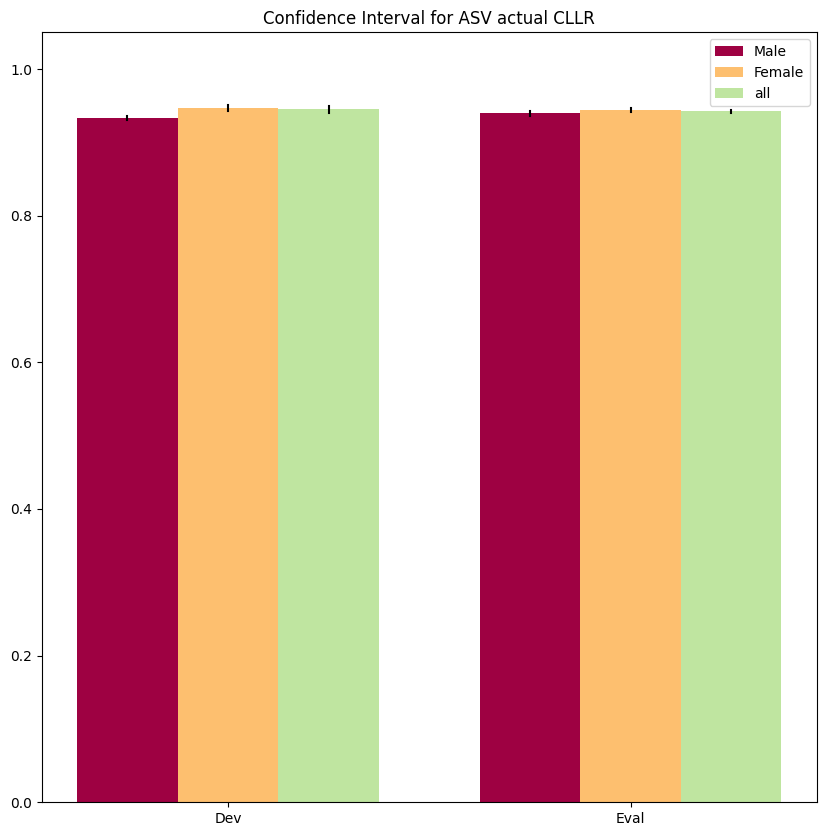

In [37]:
def metric(labels, scores):
    tar = scores[labels == 1]
    non = scores[labels == 0]
    det_all = Det(tar, non, False)
    mdcf_all  = det_all.min_dcf(ptar)
    adcf_all  = det_all.act_dcf(ptar)
    mcllr_all = det_all.min_cllr(ptar)
    acllr_all = det_all.act_cllr(ptar)
    eer_all   = det_all.eer()
    return acllr_all #, mdcf_all, adcf_all, mcllr_all, acllr_all

plot_eval_asv_metric_wrapper(eer = False,title = 'Confidence Interval for ASV actual CLLR')

# For Speaker Verification Task:

In [30]:
import pickle
file_path = './dcf_and_tdcf/dcf_avg_score/dcf/correct_flac_files/asv_results_dev_fixed_male.pkl'
results_list_dev_all = pickle.load(open(file_path, 'rb'))

In [31]:
from git_clone_liibraries.DCA_PLDA.dca_plda.scores import Key,Scores,Det
def compute_performance_with_confidence_intervals(scores,label_ground_truth,speaker_id,logid2spk_dict = None,logid2ses_dict = None, ptar=0.01, setname=None, num_boot_samples=1000, percentile=5):
    """
    Compute EER, Actual and Min Cllr, and Actual and Min DCF (for the given ptar)
    including confidence intervals obtained with bootstrapping. The function needs
    a dictionary from logid to speaker id and another dictionary from logid to session
    id in order to generate samples by speaker and session as well as by logid.
    Each bootstrap sample is composed by a random selection (with replacement)
    of speakers, sessions from those speakers and logids from those sessions.
    When there's a single logid per session, logid2ses_dict should be set to None.
    This code is very slow for large datasets. It would probably have to be optimized 
    for use in those cases. 
    scores - Scores object with the scores to be evaluated
    keylist - file with the list of keys to be evaluated
    outfile - file to write the results
    logid2spk_dict - dictionary from logid to speaker id
    logid2ses_dict - dictionary from logid to session id
    ptar - prior probability of target trials
    setname - optional name to be added to the results
    """

    print("%-32s |    EER      EERp5    EERp95 |   ACLLR ACLLRlow ACLLRup   |   MCLLR   MCLLRlow MCLLRup   |   ADCF  ADCFlow  ADCFup  |    MDCF  MDCFlow MDCFup \n"%"Key")

    randomize_by_logid = True
    if logid2ses_dict is None:
        # If this dict is not provided, do not randomize both by session and logid, just do it once
        randomize_by_logid = False

        if setname is not None:
            name="%s:%s"%(setname,name)

    # Metrics for the full key
    ascores = scores
    tar = scores[label_ground_truth == 'target']
    non = scores[label_ground_truth == 'nontarget']
    det_all = Det(tar, non, False)

    mdcf_all  = det_all.min_dcf(ptar)
    adcf_all  = det_all.act_dcf(ptar)
    mcllr_all = det_all.min_cllr(ptar)
    acllr_all = det_all.act_cllr(ptar)
    eer_all   = det_all.eer()*100

    # Keep only the speakers for which some logid is present in the key
    logid_list = np.unique(speaker_id)

    if not randomize_by_logid:
        # Assign a dummy session id to be the same as the logid
        logid2ses_dict = dict([(l, l) for l in logid_list])

    sesid_list = np.unique([logid2ses_dict[logid] for logid in logid_list]) 
    spkid_list = np.unique(speaker_id)
    
    print("Original key, num_spk = %d, num_sess = %d, num_logids = %d, num_tgt = %d, num_imp = %d, acllr = %.2f"%
        (len(np.unique(spkid_list)),
            len(np.unique(sesid_list)),
            len(np.unique(logid_list)),
            len(tar), len(non), acllr_all))

    # Lists for accumulating results over each bootstrap sample
    mdcfs, adcfs, acllrs, mcllrs, eers  = [], [], [], [], []

    for nboot in range(num_boot_samples):
        
        # Sample speakers 
        sel_spks = np.array(random.choices(spkid_list, k=len(spkid_list)))


        # Get a dict with the correct number of repetitions for each lid.
        # This number is given by the number of times the lid is repeated in 
        # sel_lids, multiplied by the number of times the session for that lid is repeated
        # in sel_sess, multiplied the number of times the speaker for that lid is repeated
        # in sel_spks
        num_rep_dict = dict()
        for lid in logid_list:
            spk = logid2spk_dict[lid]
            ses = logid2ses_dict[lid]
            nlid = len(np.where(sel_lids==lid)[0]) 
            nses = len(np.where(sel_sess==ses)[0]) 
            nspk = len(np.where(sel_spks==spk)[0]) 
            num_rep_dict[lid] = nlid*nses*nspk
        
        # For each test and enroll id, find out how many times
        # it needs to be included in the new key (could be 0, 1 or more)
        def select_indexes(llist):
            sel_idxs = []
            for j, logid in enumerate(llist):
                sel_idxs += [j]*num_rep_dict[logid]
            return np.array(sel_idxs)

        sel_test_idxs   = select_indexes(key.test_ids)
        sel_enroll_idxs = select_indexes(key.enroll_ids)

        sel_key = Key(np.array(key.test_ids)[sel_test_idxs], np.array(key.enroll_ids)[sel_enroll_idxs], key.mask[np.ix_(sel_enroll_idxs,sel_test_idxs)])

        ascores = scores.align(sel_key)
        tar = ascores.score_mat[sel_key.mask==1]
        non = ascores.score_mat[sel_key.mask==-1]
        det = Det(tar, non, sel_key)

        mdcfs.append(det.min_dcf(ptar))
        adcfs.append(det.act_dcf(ptar))
        mcllrs.append(det.min_cllr(ptar))
        acllrs.append(det.act_cllr(ptar))
        eers.append(det.eer()*100)

        print("Sample %d, num_spk = %d, num_sess = %d, num_logids = %d, num_tgt = %d, num_imp = %d, acllr = %.2f"%(nboot, 
            len(np.unique(sel_spks)),
            len(np.unique(sel_sess)),
            len(np.unique(sel_lids)),
            len(tar), len(non), acllrs[-1]))

    def get_conf_int(boot_values):
        return [np.percentile(boot_values, percentile), np.percentile(boot_values, 100-percentile)]

    mdcf_ci  = get_conf_int(mdcfs)
    adcf_ci  = get_conf_int(adcfs)
    mcllr_ci = get_conf_int(mcllrs)
    acllr_ci = get_conf_int(acllrs)
    eer_ci   = get_conf_int(eers)

    print("%-32s |  %6.2f   %6.2f  %6.2f   |  %7.4f  %7.4f  %7.4f  |  %7.4f  %7.4f  %7.4f  | %7.4f %7.4f %7.4f  | %7.4f %7.4f %7.4f  \n"%
        (name, 
        eer_all,   *eer_ci,  
        acllr_all, *acllr_ci,
        mcllr_all, *mcllr_ci,
        adcf_all,  *adcf_ci,
        mdcf_all,  *mdcf_ci))

    return

In [32]:
from git_clone_liibraries.DCA_PLDA.dca_plda.scores import Key,Scores 
#mask =np.ones((len(np.unique(results_list_dev_all['speaker_id'].values)),len(results_list_dev_all['audio_filename'].values)))
#Key(enrollids = np.unique(results_list_dev_all['speaker_id'].values),testids = results_list_dev_all['audio_filename'].values,mask =mask)

In [33]:
from git_clone_liibraries.DCA_PLDA.dca_plda.scores import Key,Scores 

scores =  results_list_dev_all['pred_scores']

label_ground_truth = results_list_dev_all['label_ground_truth']

speaker_id = results_list_dev_all['speaker_id']

compute_performance_with_confidence_intervals(scores,label_ground_truth,speaker_id,logid2spk_dict = None,logid2ses_dict = None, ptar=0.01, setname=None, num_boot_samples=1000, percentile=5)

Key                              |    EER      EERp5    EERp95 |   ACLLR ACLLRlow ACLLRup   |   MCLLR   MCLLRlow MCLLRup   |   ADCF  ADCFlow  ADCFup  |    MDCF  MDCFlow MDCFup 

Original key, num_spk = 4, num_sess = 4, num_logids = 4, num_tgt = 560, num_imp = 1232, acllr = 0.91


TypeError: 'NoneType' object is not subscriptable